# Promotion Prediction
This project aims to answer staff concerns about whether promotions are biased, identify the most important features that should drive promotion eligibility, explain models and findings, and give concrete recommendations to make promotions fairer, transparent, and defensible.  


In [1]:
# Importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, recall_score, precision_score, f1_score, make_scorer, fbeta_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

# Fairness
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds
import shap

# For encoding
import category_encoders as ce

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Loading and Initial Exploration of the Dataset 

In [2]:
# Initialise file path
filepath = 'promotion_dataset.csv'  # Update this path as necessary

# Load dataset
try:
    df = pd.read_csv(filepath)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Dataset file not found. Please check file path and/or file extension.")

Dataset loaded successfully!


In [44]:
# Preview the dataset
df.head()

,EmployeeNo,Division,Qualification,Gender,Channel_of_Recruitment,Trainings_Attended,Year_of_birth,Last_performance_score,Year_of_recruitment,Targets_met,Previous_Award,Training_score_average,State_Of_Origin,Foreign_schooled,Marital_Status,Past_Disciplinary_Action,Previous_IntraDepartmental_Movement,No_of_previous_employers,Promoted_or_Not
0,YAK/S/00001,Commercial Sales and Marketing,MSc MBA and PhD,Female,Direct Internal process,2,1986,12.5,2011,1,0,41,ANAMBRA,No,Married,No,No,0,0
1,YAK/S/00002,Customer Support and Field Operations,First Degree or HND,Male,Agency and others,2,1991,12.5,2015,0,0,52,ANAMBRA,Yes,Married,No,No,0,0
2,YAK/S/00003,Commercial Sales and Marketing,First Degree or HND,Male,Direct Internal process,2,1987,7.5,2012,0,0,42,KATSINA,Yes,Married,No,No,0,0
3,YAK/S/00004,Commercial Sales and Marketing,First Degree or HND,Male,Agency and others,3,1982,2.5,2009,0,0,42,NIGER,Yes,Single,No,No,1,0
4,YAK/S/00006,Information and Strategy,First Degree or HND,Male,Direct Internal process,3,1990,7.5,2012,0,0,77,AKWA IBOM,Yes,Married,No,No,1,0


In [45]:
# Check Data Shape
df.shape

(38312, 19)

In [46]:
# Get Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38312 entries, 0 to 38311
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   EmployeeNo                           38312 non-null  object 
 1   Division                             38312 non-null  object 
 2   Qualification                        36633 non-null  object 
 3   Gender                               38312 non-null  object 
 4   Channel_of_Recruitment               38312 non-null  object 
 5   Trainings_Attended                   38312 non-null  int64  
 6   Year_of_birth                        38312 non-null  int64  
 7   Last_performance_score               38312 non-null  float64
 8   Year_of_recruitment                  38312 non-null  int64  
 9   Targets_met                          38312 non-null  int64  
 10  Previous_Award                       38312 non-null  int64  
 11  Training_score_average      

In [47]:
# Statistical Summary of numeric columns
df.describe()

,Trainings_Attended,Year_of_birth,Last_performance_score,Year_of_recruitment,Targets_met,Previous_Award,Training_score_average,No_of_previous_employers,Promoted_or_Not
count,38312.000000,38312.000000,38312.000000,38312.000000,38312.000000,38312.000000,38312.000000,38312.000000,38312.000000
mean,2.253680,1986.209334,7.698959,2013.139695,0.352996,0.023152,55.366465,1.040953,0.084595
std,0.609443,7.646047,3.744135,4.261451,0.477908,0.150388,13.362741,1.235738,0.278282
min,2.000000,1950.000000,0.000000,1982.000000,0.000000,0.000000,31.000000,0.000000,0.000000
25%,2.000000,1982.000000,5.000000,2012.000000,0.000000,0.000000,43.000000,0.000000,0.000000
50%,2.000000,1988.000000,7.500000,2014.000000,0.000000,0.000000,52.000000,1.000000,0.000000
75%,2.000000,1992.000000,10.000000,2016.000000,1.000000,0.000000,68.000000,1.000000,0.000000
max,11.000000,2001.000000,12.500000,2018.000000,1.000000,1.000000,91.000000,6.000000,1.000000


In [3]:
# Check for nulls
df.isnull().sum()

EmployeeNo                                0
Division                                  0
Qualification                          1679
Gender                                    0
Channel_of_Recruitment                    0
Trainings_Attended                        0
Year_of_birth                             0
Last_performance_score                    0
Year_of_recruitment                       0
Targets_met                               0
Previous_Award                            0
Training_score_average                    0
State_Of_Origin                           0
Foreign_schooled                          0
Marital_Status                            0
Past_Disciplinary_Action                  0
Previous_IntraDepartmental_Movement       0
No_of_previous_employers                  0
Promoted_or_Not                           0
dtype: int64

```
1679 Qualifications missing
``` 

In [4]:
# Handle missing values by mode inputation
df['Qualification'].fillna(df['Qualification'].mode()[0], inplace=True)

# Verify no missing values remain
df.isnull().sum()

EmployeeNo                             0
Division                               0
Qualification                          0
Gender                                 0
Channel_of_Recruitment                 0
Trainings_Attended                     0
Year_of_birth                          0
Last_performance_score                 0
Year_of_recruitment                    0
Targets_met                            0
Previous_Award                         0
Training_score_average                 0
State_Of_Origin                        0
Foreign_schooled                       0
Marital_Status                         0
Past_Disciplinary_Action               0
Previous_IntraDepartmental_Movement    0
No_of_previous_employers               0
Promoted_or_Not                        0
dtype: int64

In [50]:
# Check for Duplicates
df.duplicated().sum()

np.int64(0)

In [5]:
# Drop unnecessary columns
df = df.drop(['EmployeeNo'], axis=1)
df.columns

Index(['Division', 'Qualification', 'Gender', 'Channel_of_Recruitment',
       'Trainings_Attended', 'Year_of_birth', 'Last_performance_score',
       'Year_of_recruitment', 'Targets_met', 'Previous_Award',
       'Training_score_average', 'State_Of_Origin', 'Foreign_schooled',
       'Marital_Status', 'Past_Disciplinary_Action',
       'Previous_IntraDepartmental_Movement', 'No_of_previous_employers',
       'Promoted_or_Not'],
      dtype='object')

In [6]:
# numerical features
num_cols = df.select_dtypes(include=['number']).columns
if 'Promoted_or_Not' in num_cols:
    num_cols = num_cols.drop('Promoted_or_Not')  # Exclude target variable if present
print("Numerical Features:", num_cols)

Numerical Features: Index(['Trainings_Attended', 'Year_of_birth', 'Last_performance_score',
       'Year_of_recruitment', 'Targets_met', 'Previous_Award',
       'Training_score_average', 'No_of_previous_employers'],
      dtype='object')


In [7]:
# Categorical features
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical Features:", cat_cols)

Categorical Features: Index(['Division', 'Qualification', 'Gender', 'Channel_of_Recruitment',
       'State_Of_Origin', 'Foreign_schooled', 'Marital_Status',
       'Past_Disciplinary_Action', 'Previous_IntraDepartmental_Movement'],
      dtype='object')


## Exploratory Data Analysis (EDA)

### Visualise Target Variable

In [54]:
# Check target variable distribution
print("\n" + "="*80)
print("TARGET VARIABLE DISTRIBUTION")
print("="*80)
target_counts = df['Promoted_or_Not'].value_counts()
target_percent = 100 * df['Promoted_or_Not'].value_counts(normalize=True)

print("\nDistribution of Promotions:")
print(f"  Not Promoted (0): {target_counts[0]:,} ({target_percent[0]:.2f}%)")
print(f"  Promoted (1):    {target_counts[1]:,} ({target_percent[1]:.2f}%)")
print(f"\n  Imbalance Ratio: {target_counts[0]/target_counts[1]:.1f}:1")


TARGET VARIABLE DISTRIBUTION

Distribution of Promotions:
  Not Promoted (0): 35,071 (91.54%)
  Promoted (1):    3,241 (8.46%)

  Imbalance Ratio: 10.8:1


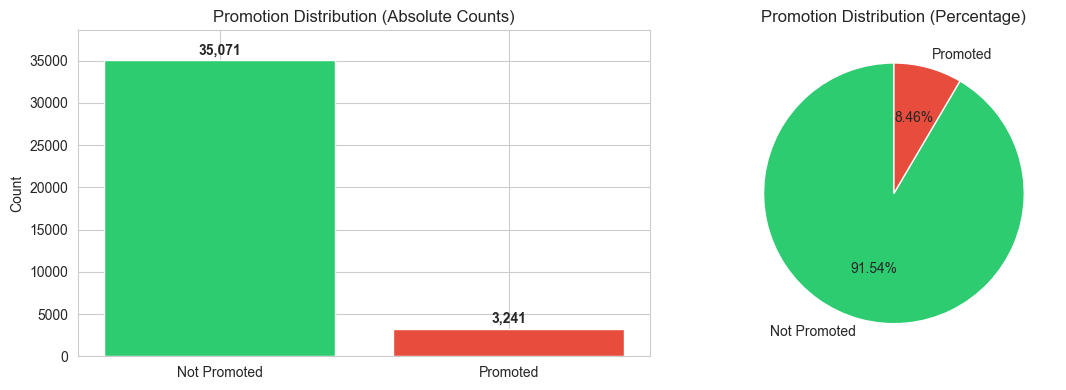

In [55]:
# Visualize target distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(['Not Promoted', 'Promoted'], target_counts.values, color=['#2ecc71', '#e74c3c'])
ax[0].set_ylabel('Count')
ax[0].set_title('Promotion Distribution (Absolute Counts)')
ax[0].set_ylim(0, max(target_counts.values) * 1.1)
for i, v in enumerate(target_counts.values):
    ax[0].text(i, v + max(target_counts.values)*0.02, f'{v:,}', ha='center', fontweight='bold')

ax[1].pie(target_counts.values, labels=['Not Promoted', 'Promoted'], 
          autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
ax[1].set_title('Promotion Distribution (Percentage)')

plt.tight_layout()
plt.show()

```
NOTE: This shows a highly imbalanced target and would require proper handling
```

### Visualise Features

In [8]:
# List of categorical features
cat_cols

Index(['Division', 'Qualification', 'Gender', 'Channel_of_Recruitment',
       'State_Of_Origin', 'Foreign_schooled', 'Marital_Status',
       'Past_Disciplinary_Action', 'Previous_IntraDepartmental_Movement'],
      dtype='object')

In [57]:
# Visualise promotions by selected categorical columns (bar if >3 categories, pie otherwise)
promoted = df[df['Promoted_or_Not'] == 1].copy()

# Filter to existing columns and compute category counts
available_cols = [c for c in cat_cols if c in promoted.columns]
missing_cols = [c for c in cat_cols if c not in promoted.columns]
if missing_cols:
    print("Missing columns (skipped):", missing_cols)

bar_cols = []
pie_cols = []
for c in available_cols:
    n_cat = promoted[c].value_counts(dropna=False).shape[0]
    if n_cat > 3:
        bar_cols.append(c)
    else:
        pie_cols.append(c)

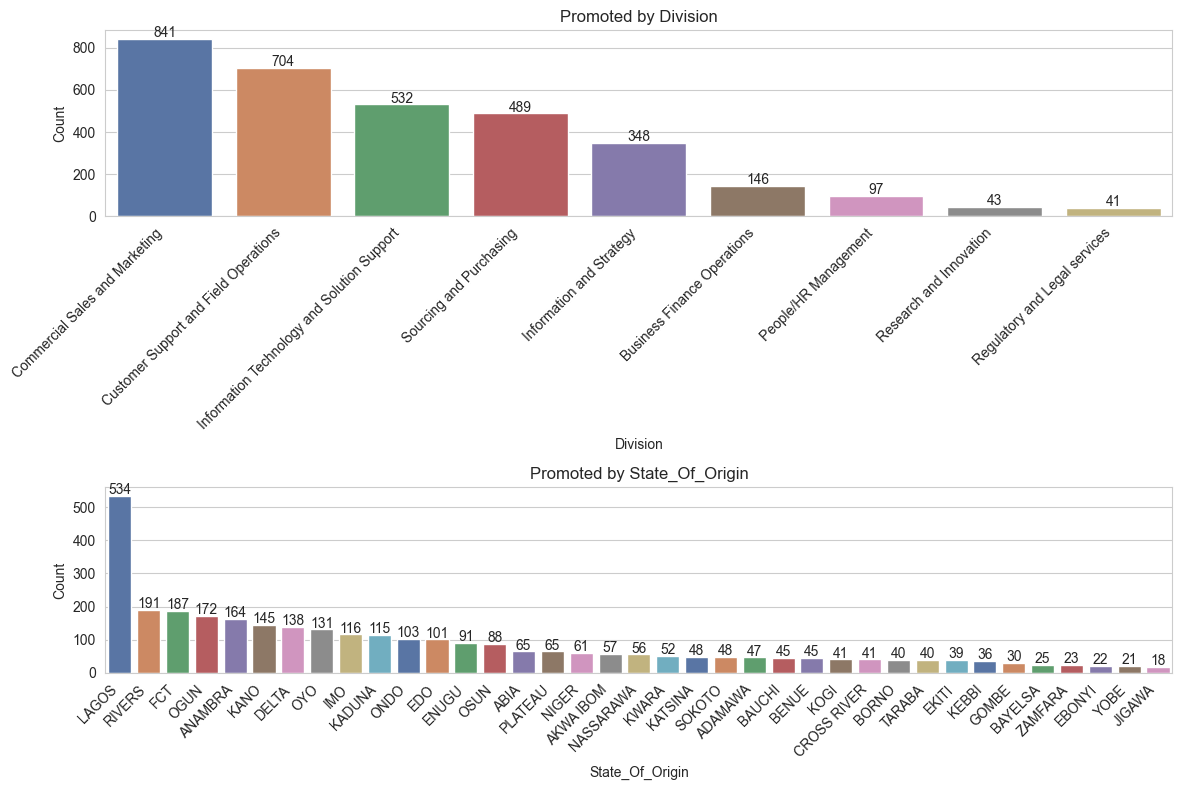

In [58]:
# Bar charts subplot (for columns with more than 3 categories)
if bar_cols:
    n = len(bar_cols)
    ncols = 1
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(bar_cols):
        counts = promoted[col].value_counts(dropna=False).sort_values(ascending=False)
        sns.barplot(x=counts.index.astype(str), y=counts.values, ax=axes[i], palette='deep')
        axes[i].set_title(f'Promoted by {col}')
        axes[i].set_ylabel('Count')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
        for j, v in enumerate(counts.values):
            axes[i].text(j, v + max(counts.values)*0.01, f'{int(v):,}', ha='center')
    # hide unused axes
    for k in range(i+1, len(axes)):
        axes[k].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No columns require bar charts (all have 3 or fewer categories).")

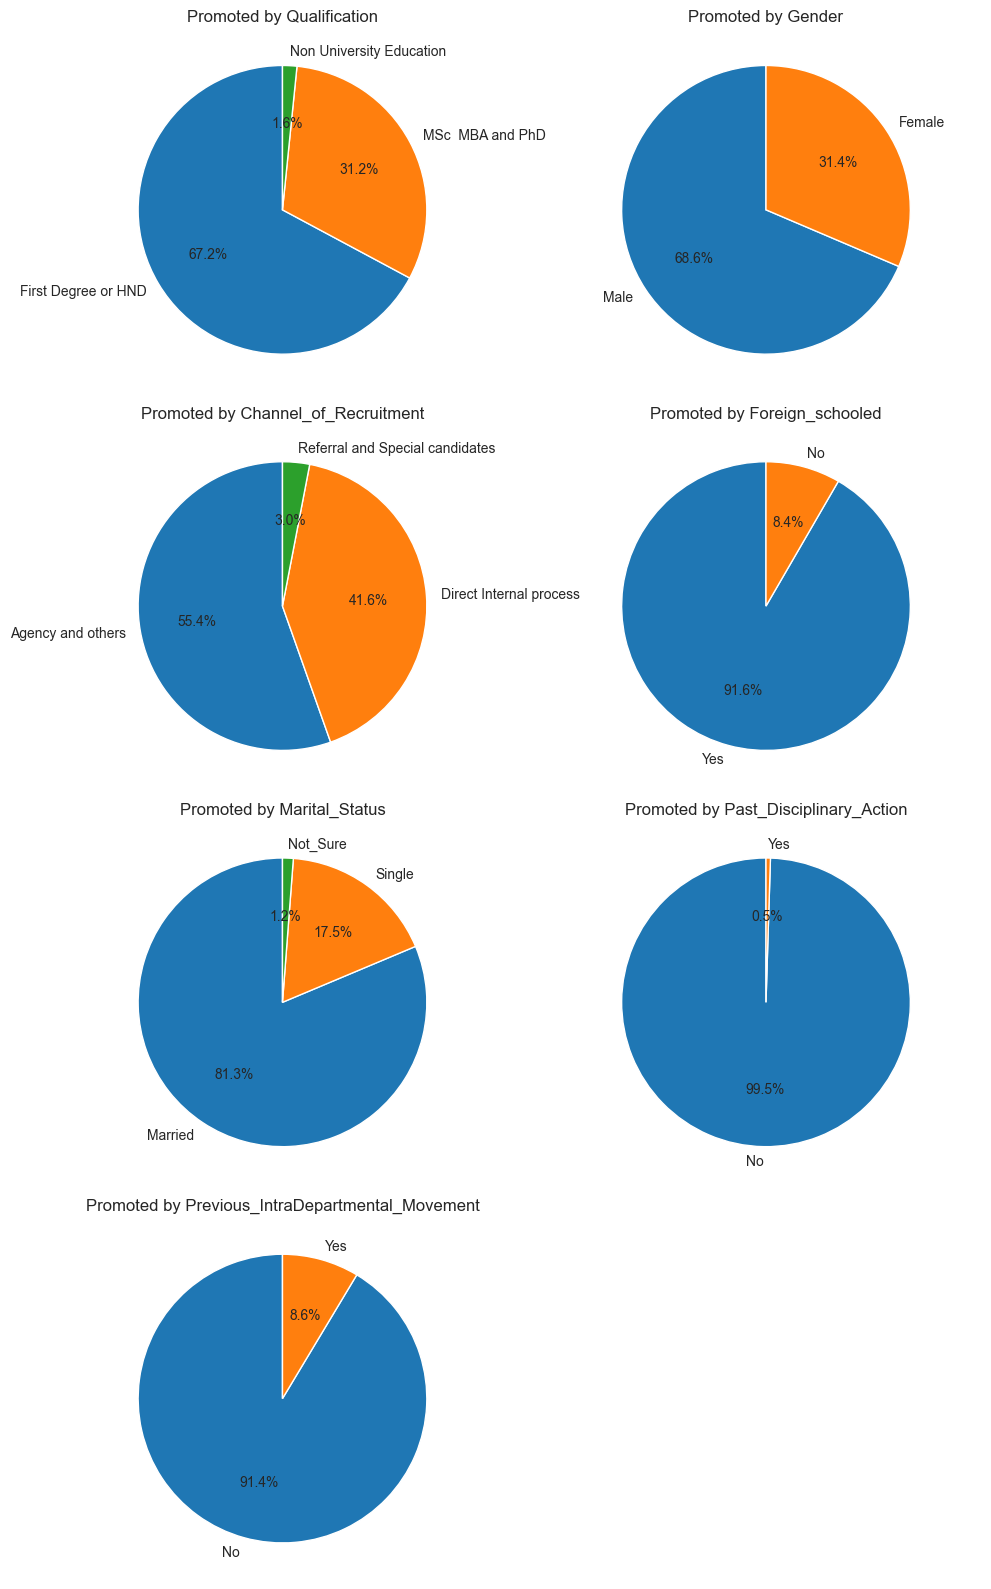

In [59]:
# Pie charts subplot (for columns with 3 or fewer categories)
if pie_cols:
    n = len(pie_cols)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(pie_cols):
        counts = promoted[col].value_counts(dropna=False)
        labels = [str(l) for l in counts.index]
        my_colors = sns.color_palette('tab10', n_colors=len(labels))
        axes[i].pie(counts.values, labels=labels, autopct='%1.1f%%', startangle=90, colors=my_colors)
        axes[i].set_title(f'Promoted by {col}')
    # hide unused axes
    for k in range(i+1, len(axes)):
        axes[k].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No columns require pie charts (all have more than 3 categories).")

```
NOTE: Absolute counts are heavily influenced by base rates (e.g., more males in workforce → more promoted males). These counts raise questions and justify further rate-based and statistical tests — which I further performed.
```

## Data Pre-processing for Predicting Promotion

### Check and Handle Outliers

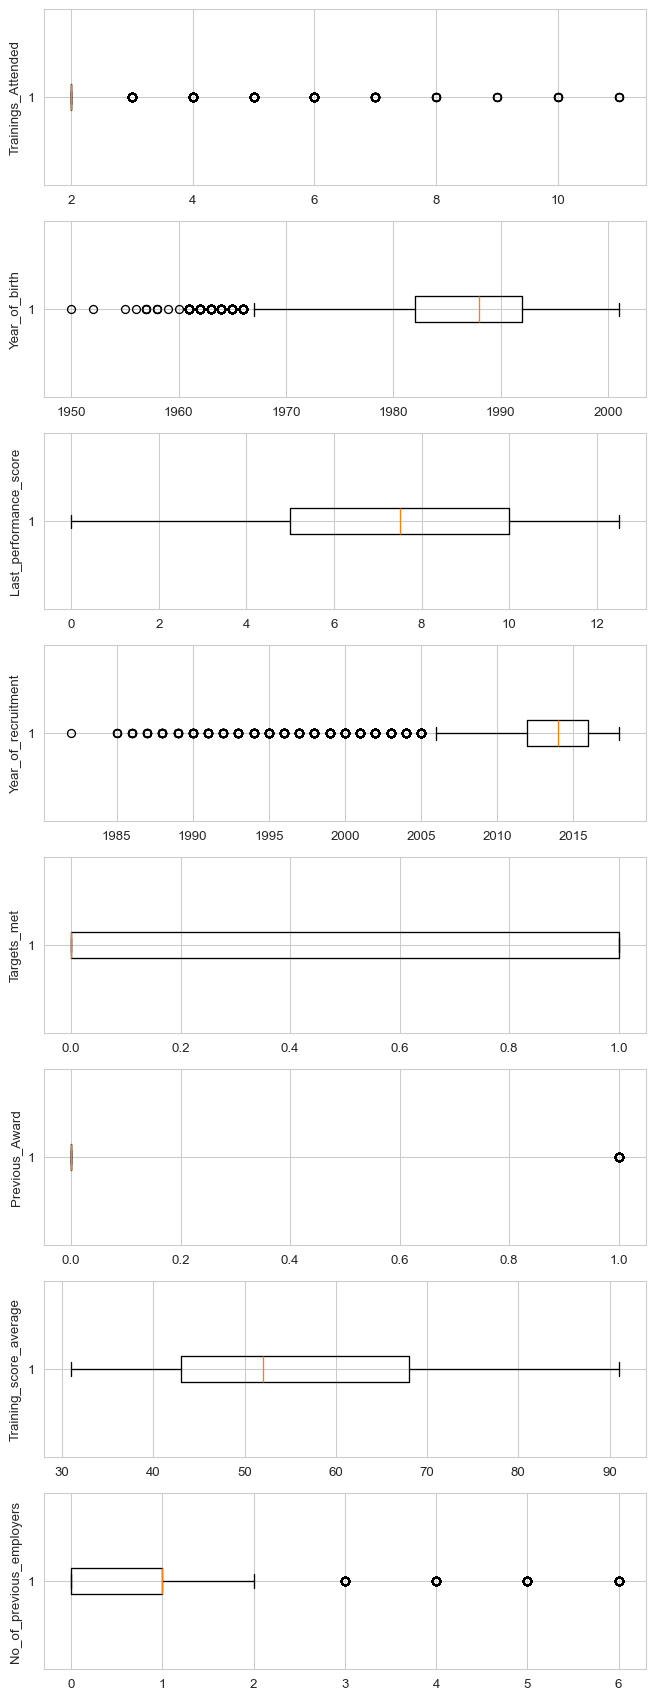

In [60]:
# Check for outliers in numerical features using box plots
fig, axs = plt.subplots(len(num_cols), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(num_cols):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

```
No Outliers observed
```

### Encode Categorical Columns using Target or OneHotEncoder

In [9]:
# Create a copy of the dataframe for encoding
df_encoded2 = df.copy()
df_encoded2.head()

,Division,Qualification,Gender,Channel_of_Recruitment,Trainings_Attended,Year_of_birth,Last_performance_score,Year_of_recruitment,Targets_met,Previous_Award,Training_score_average,State_Of_Origin,Foreign_schooled,Marital_Status,Past_Disciplinary_Action,Previous_IntraDepartmental_Movement,No_of_previous_employers,Promoted_or_Not
0,Commercial Sales and Marketing,MSc MBA and PhD,Female,Direct Internal process,2,1986,12.5,2011,1,0,41,ANAMBRA,No,Married,No,No,0,0
1,Customer Support and Field Operations,First Degree or HND,Male,Agency and others,2,1991,12.5,2015,0,0,52,ANAMBRA,Yes,Married,No,No,0,0
2,Commercial Sales and Marketing,First Degree or HND,Male,Direct Internal process,2,1987,7.5,2012,0,0,42,KATSINA,Yes,Married,No,No,0,0
3,Commercial Sales and Marketing,First Degree or HND,Male,Agency and others,3,1982,2.5,2009,0,0,42,NIGER,Yes,Single,No,No,1,0
4,Information and Strategy,First Degree or HND,Male,Direct Internal process,3,1990,7.5,2012,0,0,77,AKWA IBOM,Yes,Married,No,No,1,0


In [10]:
# Create Binary map for yes/no fields
binary_map = {'Yes':1, 'No':0}
binary_col = ['Foreign_schooled','Past_Disciplinary_Action','Previous_IntraDepartmental_Movement']
for col in binary_col:
    if col in df_encoded2.columns:
        df_encoded2[col] = df_encoded2[col].map(binary_map)

In [11]:
# Keep a column for auditing sensitive attributes
sensitive_features = ['Gender', 'State_Of_Origin', 'Marital_Status']

In [12]:
# Split into features and target variable
X = df_encoded2.drop('Promoted_or_Not', axis=1).copy()
y = df_encoded2['Promoted_or_Not'].copy()

In [13]:
# Encode categorical variables using Target or One-Hot encoding (we'll use target encoding for ordinal-like, one-hot for high-cardinality)
ohe_cols = [c for c in cat_cols if df_encoded2[c].nunique() <= 10]
te_cols = [c for c in cat_cols if c not in ohe_cols]

In [14]:
# Apply encoders
if ohe_cols:
    X = pd.get_dummies(X, columns=ohe_cols, drop_first=False)

if te_cols:
    te = ce.TargetEncoder(cols=te_cols)
    X[te_cols] = te.fit_transform(X[te_cols], y)

### Check Correlation Between Features and Target

In [68]:
# Concatenate the target variable to the features DataFrame
df_combined = pd.concat([X, y], axis=1)

In [69]:
# Determine correlation of features with target
corr = df_combined.corr()
corr_target = corr['Promoted_or_Not'].sort_values(ascending=False)
print("CORRELATION OF FEATURES WITH TARGET VARIABLE 'Promoted_or_Not'")
print("="*80 + "\n")
print(corr_target)

CORRELATION OF FEATURES WITH TARGET VARIABLE 'Promoted_or_Not'

Promoted_or_Not                                           1.000000
Targets_met                                               0.224518
Previous_Award                                            0.201434
Training_score_average                                    0.178448
Last_performance_score                                    0.119690
Division_Information Technology and Solution Support      0.031617
State_Of_Origin                                           0.031455
Qualification_MSc  MBA and PhD                            0.026600
Channel_of_Recruitment_Referral and Special candidates    0.019354
Year_of_birth                                             0.017991
Division_Sourcing and Purchasing                          0.017084
Year_of_recruitment                                       0.012287
Division_Information and Strategy                         0.010523
Gender_Female                                             0.01043

```NOTE```  

**Interpretation:** Targets_met, Previous_Award, and Training_score_average show the strongest linear relationships with promotions.

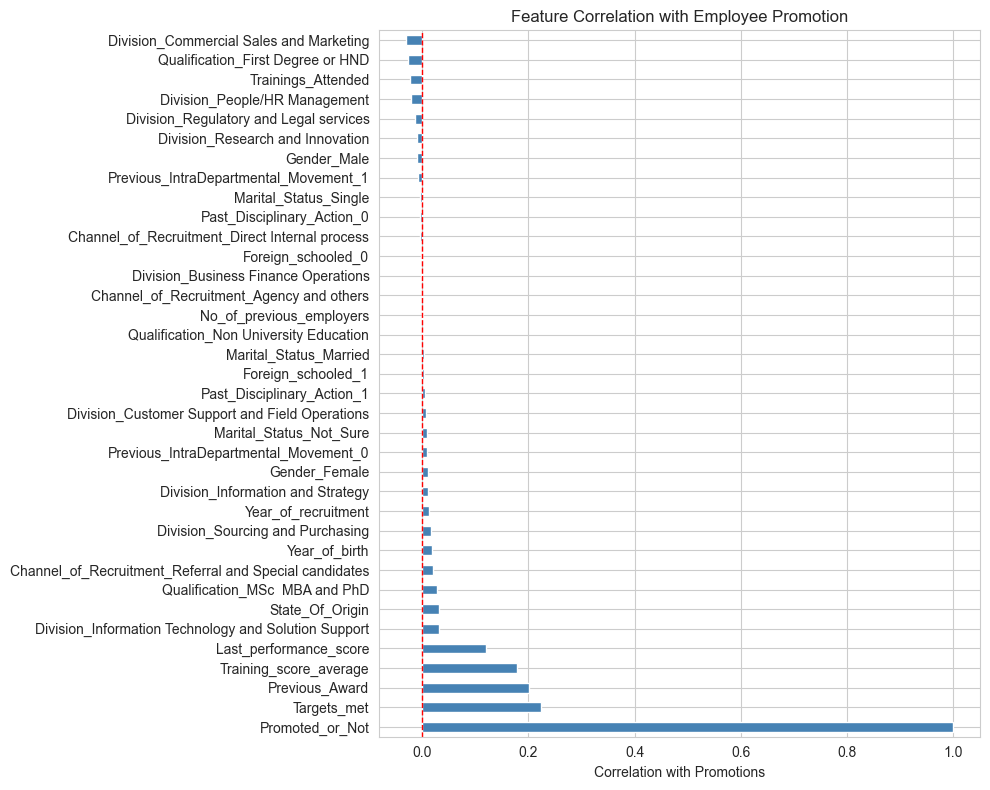

In [ ]:
# Visualize feature correlation with Target
plt.figure(figsize=(10, 8))
corr_target.plot(kind='barh', color='steelblue')
plt.xlabel('Correlation with Promotions')
plt.title('Feature Correlation with Employee Promotion')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

## Determine Model Performance on Baseline Data
In this section, I will first determine how the models perform on the baseline data, i.e. dataset whose features have not been engineered yet. We can then compare this performance down the line.

### Train Test Split and Scaling

In [15]:
# Split while preserving sensitive attributes in the holdout for fairness checks
X_train, X_test, y_train, y_test, data_train_idx, data_test_idx = train_test_split(
    X, y, df_encoded2.index, test_size=0.2, random_state=42, stratify=y)

print('Train size:', X_train.shape, 'Test size:', X_test.shape)

Train size: (30649, 35) Test size: (7663, 35)


In [16]:
# Keep sensitive attributes aligned with the split
A_train = df_encoded2.loc[data_train_idx, sensitive_features]
A_test = df_encoded2.loc[data_test_idx, sensitive_features]

In [17]:
# Keep unscaled copies
X_train_unscaled = X_train.copy() if hasattr(X_train, "copy") else pd.DataFrame(X_train)
X_test_unscaled  = X_test.copy()  if hasattr(X_test,  "copy") else pd.DataFrame(X_test)

# Compare scalers
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

### Build Models

In [18]:
# Define Helper Function for Model Evaluation
def evaluate_model(model, X_train, y_train, X_test, y_test, use_smote=False):
    """
    Trains and evaluates a classification model.
    Optionally applies SMOTE for resampling imbalanced data.

    Parameters:
        model: scikit-learn model object
        X_train, y_train, X_test, y_test: training and testing sets
        use_smote: bool, whether to apply SMOTE (for KNN in this example)

    Returns:
        dict: containing model name and performance metrics
    """
    if use_smote:
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else np.zeros_like(y_pred)

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba),
        'Confusion Metrix': confusion_matrix(y_test, y_pred)
    }

In [19]:
# Define Models to Compare
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', 
                        max_iter=1000, 
                        random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced',
                        max_depth=5,
                        min_samples_split=50,
                        min_samples_leaf=20,
                        random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced',
                        n_estimators=100,
                        max_depth=10,
                        min_samples_split=50,
                        min_samples_leaf=20,
                        random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100,
                        learning_rate=0.1,
                        max_depth=5,
                        min_samples_split=50,
                        min_samples_leaf=20,
                        random_state=42),
    'KNN (SMOTE)': KNeighborsClassifier(n_neighbors=5),
    'XGB Classifier': xgb.XGBClassifier(random_state=42, 
                        use_label_encoder=False, 
                        eval_metric='logloss'),
    'SVC' : SVC(class_weight='balanced',
                        probability=True)
}

In [ ]:
# Train and Evaluate All Models
results = []
for scaler_name, scaler in scalers.items():
    Xtr = scaler.fit_transform(X_train_unscaled)
    Xte = scaler.transform(X_test_unscaled)

    # evaluate models (uses your evaluate_model and models dict)
    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")
        use_smote = True if 'KNN' in model_name else False
        metrics = evaluate_model(clone(model), Xtr, y_train, Xte, y_test, use_smote=use_smote)
        metrics['Model'] = model_name
        metrics['Scaler'] = scaler_name
        results.append(metrics)
    print("\nAll models have been trained succesfully!")

# Convert results to DataFrame
results_df = pd.DataFrame(results)


Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...

Training KNN (SMOTE)...

Training XGB Classifier...

Training SVC...

All models have been trained succesfully!

Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...

Training KNN (SMOTE)...

Training XGB Classifier...

Training SVC...

All models have been trained succesfully!


In [88]:
# Display Model Comparison Summary
print("\n" + "=" * 80)
print("COMPARISON SUMMARY 'UNTUNED' MODELS AND UNENGINEERED FEATURES")
print("=" * 80)
print(results_df.to_string(index=False))


COMPARISON SUMMARY 'UNTUNED' MODELS AND UNENGINEERED FEATURES
 Accuracy   Recall  Precision  F1-Score  AUC-ROC           Confusion Metrix               Model         Scaler
 0.759624 0.839506   0.238387  0.371331 0.874688 [[5277, 1738], [104, 544]] Logistic Regression StandardScaler
 0.681456 0.876543   0.193923  0.317585 0.847168  [[4654, 2361], [80, 568]]       Decision Tree StandardScaler
 0.706512 0.842593   0.202748  0.326848 0.862312 [[4868, 2147], [102, 546]]       Random Forest StandardScaler
 0.942320 0.341049   0.936441  0.500000 0.907006   [[7000, 15], [427, 221]]   Gradient Boosting StandardScaler
 0.801122 0.496914   0.211842  0.297048 0.714978 [[5817, 1198], [326, 322]]         KNN (SMOTE) StandardScaler
 0.942581 0.371914   0.879562  0.522777 0.900931   [[6982, 33], [407, 241]]      XGB Classifier StandardScaler
 0.734830 0.847222   0.221193  0.350799 0.857996  [[5082, 1933], [99, 549]]                 SVC StandardScaler
 0.757667 0.837963   0.236601  0.369011 0.873163 

```NOTE```  

**Best precision/accuracy:** Gradient Boosting — Precision: 0.94, Accuracy: 0.94, Recall: 0.34.  
**Interpretation:** Very low false positive rate; but misses many actual promotions (low recall).  
**Best recall:** 
* SVC — Recall: 0.84, Precision: 0.22, Accuracy: 0.73.
* Random Forest — Recall: 0.84, Precision: 0.20, Accuracy: 0.70.  
**Interpretation:** Good at finding promotable staff but many false positives.  

Choice depends on business objective: Do we prefer a conservative rule (few false promotions — higher precision) or inclusive identification (find most promotable staff — higher recall)? I recommend a hybrid two-stage approach.

## Hyperparameter Tuning with GridSearchCV

When using GridsearchCV, chose any of the following scorings based on what I want to improve
| Score name | Improves |
|------------|----------|
| accuracy | Overall accuracy |
| precision | Precision. Ability to avoid false positives |
| recall | recall. Ability to avoid false negatives |
| f1 | Balance between recall and precision |
| balanced_accuracy | Accuracy in imbalanced datasets |
| r2 | For regression models. Improves overall variance |
| neg_mean_squared_error | For regression models. Reduces large errors more strongly |
| neg_mean_absolute_error | For regression models. Average error magnitude; robust to outliers |
| neg_root_mean_squared_error | For regression models. For MSE but interpretable in raw units of target |
| neg_mean_absolute_percentage_error | For regression models. Improves percentage accuracy; useful when scale varies |
| neg_median_absolute_error | For regression models. Robust to outliers; uses median instead of mean |

### Tuning Logistic Regression Model

In [ ]:
# Hyperparameter Tuning for Logistic Regression Model
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000, 2000],
    'class_weight': ['balanced', None]
}

lr_grid = GridSearchCV(LogisticRegression(random_state=42), 
                       param_grid=lr_param_grid, 
                       cv=5,
                       scoring='f1',
                       verbose=2,
                       n_jobs=-1)

lr_grid.fit(Xtr, y_train)

In [ ]:
# Print best parameters from GridSearchCV
print("Best Parameters from GridSearchCV for Logistic Regression:")
print(lr_grid.best_params_)
print("\nBest Estimator from GridSearchCV for Logistic Regression:")
print(lr_grid.best_estimator_)
print("\nBest Score:", lr_grid.best_score_)

In [ ]:
# Make predictions with the best estimator
best_lr_model = lr_grid.best_estimator_
lr_grid_pred = best_lr_model.predict(X_test)

In [ ]:
# Evaluate the tuned Logistic Regression model
evaluate_model(clone(best_lr_model), Xtr, y_train, Xte, y_test, use_smote=use_smote)

In [ ]:
# Print classification report for tuned Logistic Regression
print(classification_report(y_test, lr_grid_pred))

### Tuning SVC Model

In [20]:
# Hyperparameter Tuning for SVC Model
param_grid_svc_1 = {'C': [0.1, 1, 10, 100, 1000], 
			'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
			'kernel': ['rbf']} 

svc_grid_1 = GridSearchCV(SVC(), 
                          param_grid_svc_1, 
                          refit = True, 
                          verbose = 3,
                          scoring='f1')
 
svc_grid_1.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.000 total time= 1.8min
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.000 total time= 1.7min
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.000 total time= 1.7min
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.000 total time= 1.7min
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.000 total time= 1.8min
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.000 total time=  43.9s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.000 total time=  46.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.000 total time=  44.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.000 total time=  42.3s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.000 total time=  45.7s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.150 total time=  10.9s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [21]:
# Print best parameters from GridSearchCV
print("Best Parameters from GridSearchCV for SVC:")
print(svc_grid_1.best_params_)
print("\nBest Estimators from GridSearchCV for SVC:")
print(svc_grid_1.best_estimator_)

Best Parameters from GridSearchCV for SVC:
{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

Best Estimators from GridSearchCV for SVC:
SVC(C=100, gamma=0.01)


In [22]:
# Make predictions with the best estimator
svc_best_model = svc_grid_1.best_estimator_
svc_grid_1_pred = svc_best_model.predict(X_test) 

In [27]:
# Evaluate the tuned SVC model
svc_eval_results = evaluate_model(clone(svc_best_model), X_train, y_train, X_test, y_test)

In [33]:
# Display evaluation results for SVC
print("\n" + "=" * 80)
print("Evaluation Results for Tuned SVC Model:")
print("=" * 80)
svc_eval_results



Evaluation Results for Tuned SVC Model:


{'Accuracy': 0.9390578102570795,
 'Recall': 0.35030864197530864,
 'Precision': 0.8315018315018315,
 'F1-Score': 0.49294245385450597,
 'AUC-ROC': 0.5,
 'Confusion Metrix': array([[6969,   46],
        [ 421,  227]])}

### Tuning RandomForest Model

In [ ]:
# Tuning RandomForest Model
rf_param_grid_1 = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False],
    'class_weight': ['balanced'],
}

rf_grid_1 = GridSearchCV(RandomForestClassifier(), 
                         param_grid=rf_param_grid_1, 
                         cv=5,
                         scoring='precision')
rf_grid_1.fit(X_train, y_train)

In [ ]:
# Print best parameters from GridSearchCV for RandomForest
print("Best Parameters:", rf_grid_1.best_params_)
print("\nBest Estimator:", rf_grid_1.best_estimator_)

In [ ]:
# Make predictions with the best estimator
best_rf_model = rf_grid_1.best_estimator_
rf_grid_1_pred = best_rf_model.predict(X_test) 

In [ ]:
# Evaluate tuned RandomForest model
evaluate_model(clone(best_rf_model), Xtr, y_train, Xte, y_test, use_smote=use_smote)

In [ ]:
# Print classification report for tuned RandomForest
print(classification_report(y_test, rf_grid_1_pred))

### Tuning Decision Tree Model

In [ ]:
# Set up the parameter grid for GridSearchCV
dt_param_grid_1 = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'class_weight': ['balanced', {0: 1, 1: 2}, {0: 1, 1: 3}]
}

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

In [ ]:
# Set up GridSearchCV
dt_grid_1 = GridSearchCV(estimator=dt_model, param_grid=dt_param_grid_1,
                           scoring='f1', 
                           cv=5, 
                           verbose=2, 
                           n_jobs=-1)

# Fit GridSearchCV
dt_grid_1.fit(X_train, y_train)

In [ ]:
# Print the best parameters and best score
print("Best Parameters:", dt_grid_1.best_params_)
print("\nBest Estimator:", dt_grid_1.best_estimator_)
print("\nBest Score:", dt_grid_1.best_score_)

In [ ]:
# Make predictions with the best estimator
best_dt_model = dt_grid_1.best_estimator_
dt_grid_1_pred = best_dt_model.predict(X_test)

In [ ]:
# Evaluate the model
print(classification_report(y_test, dt_grid_1_pred))
print(confusion_matrix(y_test, dt_grid_1_pred))

## Global feature importance & interpretability

### For Logistic Regression — coefficients

Top positive coefficients (LR):
Training_score_average                            15.260171
Division_Commercial Sales and Marketing            3.932522
Division_People/HR Management                      3.416400
Targets_met                                        2.609909
Previous_Award                                     1.823292
Year_of_birth                                      1.578972
Division_Regulatory and Legal services             1.311351
Division_Customer Support and Field Operations     1.281257
Division_Business Finance Operations               1.098307
Last_performance_score                             0.666494
dtype: float64

Top negative coefficients (LR):
Previous_IntraDepartmental_Movement_0                  -1.101720
Foreign_schooled_0                                     -1.121423
Gender_Male                                            -1.157344
Gender_Female                                          -1.171029
Foreign_schooled_1                                     -1.20

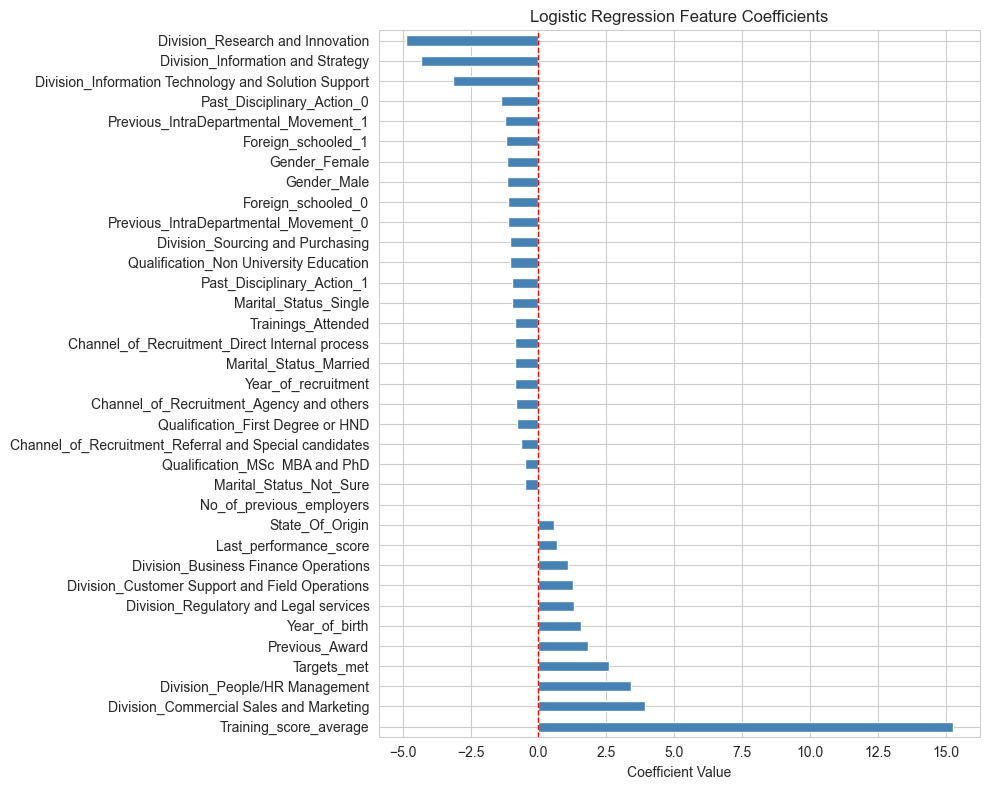

In [ ]:
# Train a fresh LR on scaled data (StandardScaler from results loop)
fresh_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
fresh_lr.fit(Xtr, y_train)

coef = pd.Series(fresh_lr.coef_[0], index=X_train_unscaled.columns).sort_values(ascending=False)
print('Top positive coefficients (LR):')
print(coef.head(10))
print('\nTop negative coefficients (LR):')
print(coef.tail(10))

# Visualize coefficients
plt.figure(figsize=(10, 8))
coef.plot(kind='barh', color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Feature Coefficients')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

```NOTE```  
**Interpretation:** After accounting for other features, 
* Training_score_average has by far the largest positive coefficient in the regression — suggesting it is the most powerful numeric predictor.
* Division affiliation strongly affects odds in both directions.

### Using SHAP for richer explanations on Tree-based models

In [94]:
# Train XGB Classifier on scaled data first
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(Xtr, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [95]:
# Create SHAP explainer for the trained XGB model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(Xte)

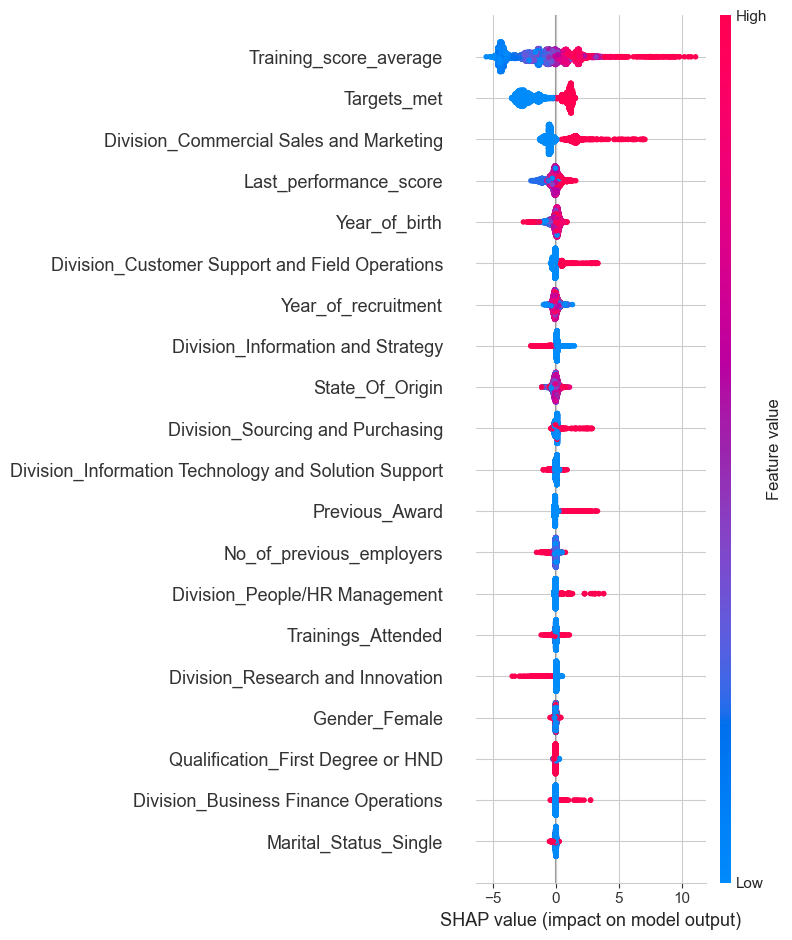

In [96]:
# SHAP summary plot (shows feature importance by average |SHAP value|)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, Xte, feature_names=X_train_unscaled.columns, show=False)
plt.tight_layout()
plt.show()

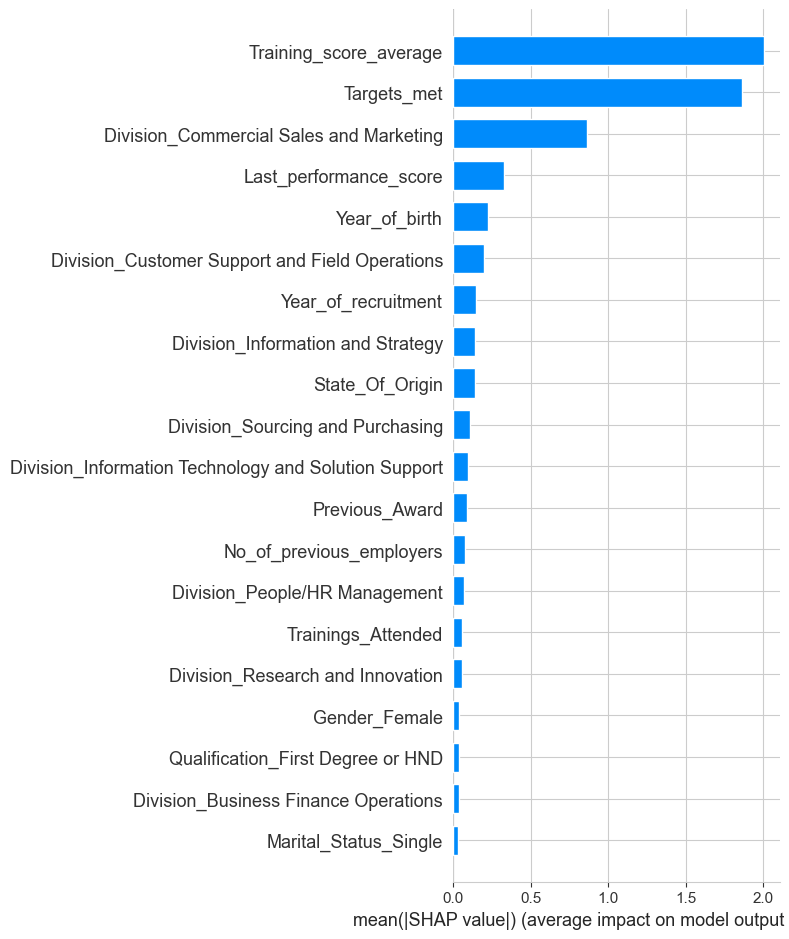

In [97]:
# SHAP bar plot (mean absolute SHAP values per feature)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, Xte, feature_names=X_train_unscaled.columns, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

```NOTE```  
**Interpretation:** SHAP confirms the same major drivers: training score, targets met, division, and last performance are the features with highest contribution to model predictions.  

Therefore, the primary features to recommend for promotion eligibility scoring (ordered):
* Training_score_average — most consistent, largest effect.
* Targets_met (achievement of targets/KPIs) — strong positive.
* Previous_Award / Recognition — signal of prior merit.
* Last_performance_score — direct performance appraisal.
* Division (not a merit metric but a strong predictor):
    - Commercial Sales & Marketing and People/HR positively associated
    - Some divisions (IT, Strategy, Research) negatively associated.
* Postgraduate Qualification (MSc/MBA/PhD) — modest positive effect.
* State of Origin — small signal but visible in EDA (with Lagos having the highest promotions).
* Recruitment Channel — with large differences in counts, should be normalised/corrected if policy shouldn’t favor one group.  

## Fairness audit — Group-wise metrics

The following metrics will be considered:  
1. Overall selection rate:  
What: fraction of all instances predicted positive by the model (predicted_positive / total).  
Implies: how frequently the model grants the favorable outcome overall. Low overall selection rate may reflect conservative behavior or class imbalance.

2. Overall TPR (overall true positive rate):  
What: fraction of actual positives correctly predicted (TP / (TP + FN)).  
Implies: model’s ability to detect positive cases overall. Low TPR means many real positives are missed.

3. Selection rate (per-group):  
What: fraction of members of a specific group predicted positive.  
Implies: how often each group receives the favorable prediction. Differences across groups indicate disparate treatment at the output level.

4. TPR (per-group):  
What: true positive rate computed for a specific group (TP_group / (TP_group + FN_group)).  
Implies: whether the model is equally good at detecting positives for each group. Large TPR gaps imply unequal error rates (one group suffers more false negatives).

5. Selection rate ratio (min / max):  
What: smallest group selection rate divided by largest group selection rate.  
Implies: a simple disparity measure. Values near 1 mean parity; much less than 1 means under‑selection of some groups.

6. AIR — Adverse Impact Ratio (minor_group_rate / major_group_rate):  
What: ratio of selection rates used as the “four‑fifths rule” heuristic.  
Implies: if AIR < 0.8 (i.e., less than 80%), it flags potential disparate impact under common regulatory guidance. If AIR ≥ 0.8 it’s less likely to be considered adverse by that rule, but still inspect context and other metrics.


In [114]:
# Check selection rates and true positive rates for Gender
sensitive = 'Gender'

# Get the sensitive attribute aligned to X_test
sensitive_attribute = A_test[sensitive].values

# Use MetricFrame on XGB Classifier predictions
preds_xgb = xgb_model.predict(X_test)
mf = MetricFrame(metrics={'selection_rate': selection_rate, 'tpr': true_positive_rate},
                 y_true=y_test, y_pred=preds_xgb, sensitive_features=sensitive_attribute)
print("\n" + "="*80)
print(f"FAIRNESS AUDIT: {sensitive.upper()}")
print("="*80)
print('Overall metrics:')
print('Overall selection rate:', selection_rate(y_test, preds_xgb))
print('Overall TPR:', true_positive_rate(y_test, preds_xgb))
print('\nPer-group metrics:')
print(mf.by_group)

# Compute Disparity (ratio)
groups = mf.by_group.index.tolist()
sel_rates = mf.by_group['selection_rate']
print('\nSelection rate ratio (min / max):', sel_rates.min()/sel_rates.max())

# Adverse Impact Rule of Thumb
major_group_rate = sel_rates.max()
minor_group_rate = sel_rates.min()
air = minor_group_rate / major_group_rate
print('Adverse Impact Ratio (AIR):', air)


FAIRNESS AUDIT: GENDER
Overall metrics:
Overall selection rate: 0.9364478663708731
Overall TPR: 0.9768518518518519

Per-group metrics:
                     selection_rate       tpr
sensitive_feature_0                          
Female                     0.985042  0.985437
Male                       0.915955  0.972851

Selection rate ratio (min / max): 0.9298645780940172
Adverse Impact Ratio (AIR): 0.9298645780940172


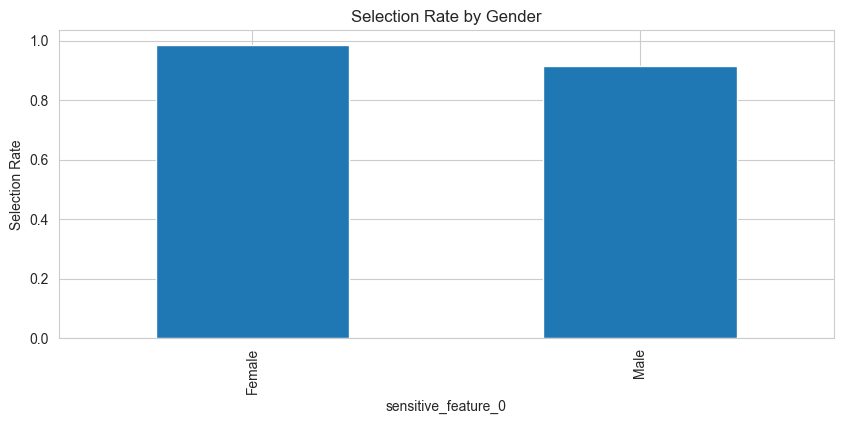

In [115]:
# Visual checks (selection rates by group)
plt.figure(figsize=(10,4))
sel_rates.plot(kind='bar')
plt.title('Selection Rate by '+sensitive)
plt.ylabel('Selection Rate')
plt.show()

```NOTE```  

**Interpretation:**  
The AIR of ~0.93 is above the conservative 0.80 (4/5ths) threshold used in many legal and HR contexts to flag adverse impact. That implies no clear adverse impact against either gender based on the audited metric.  

Females actually appear to have a higher selection rate than males in the model's selection results — this explains perception vs reality: absolute counts may show more promoted males because there are more males employed, but rates show higher female selection probability.

In [116]:
# Check selection rates and true positive rates for Marital_Status
sensitive = 'Marital_Status'

# Get the sensitive attribute aligned to X_test
sensitive_attribute = A_test[sensitive].values

# Use MetricFrame on XGB Classifier predictions
preds_xgb = xgb_model.predict(X_test)
mf = MetricFrame(metrics={'selection_rate': selection_rate, 'tpr': true_positive_rate},
                 y_true=y_test, y_pred=preds_xgb, sensitive_features=sensitive_attribute)
print("\n" + "="*80)
print(f"FAIRNESS AUDIT: {sensitive.upper()}")
print("="*80)
print('Overall metrics:')
print('Overall selection rate:', selection_rate(y_test, preds_xgb))
print('Overall TPR:', true_positive_rate(y_test, preds_xgb))
print('\nPer-group metrics:')
print(mf.by_group)

# Compute Disparity (ratio)
groups = mf.by_group.index.tolist()
sel_rates = mf.by_group['selection_rate']
print('\nSelection rate ratio (min / max):', sel_rates.min()/sel_rates.max())

# Adverse Impact Rule of Thumb
major_group_rate = sel_rates.max()
minor_group_rate = sel_rates.min()
air = minor_group_rate / major_group_rate
print('Adverse Impact Ratio (AIR):', air)


FAIRNESS AUDIT: MARITAL_STATUS
Overall metrics:
Overall selection rate: 0.9364478663708731
Overall TPR: 0.9768518518518519

Per-group metrics:
                     selection_rate       tpr
sensitive_feature_0                          
Married                    0.937460  0.973129
Not_Sure                   0.939024  1.000000
Single                     0.931802  0.991525

Selection rate ratio (min / max): 0.9923084811814173
Adverse Impact Ratio (AIR): 0.9923084811814173


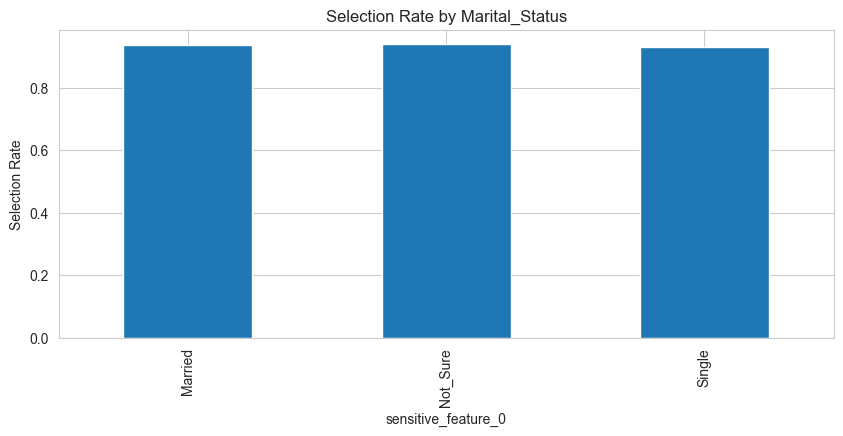

In [117]:
# Visual checks (selection rates by group)
plt.figure(figsize=(10,4))
sel_rates.plot(kind='bar')
plt.title('Selection Rate by '+sensitive)
plt.ylabel('Selection Rate')
plt.show()

```NOTE```  

**Interpretation:**  
Very near parity — no adverse impact detected for marital status.

In [118]:
# Check selection rates and true positive rates for State_Of_Origin
sensitive = 'State_Of_Origin'

# Get the sensitive attribute aligned to X_test
sensitive_attribute = A_test[sensitive].values

# Use MetricFrame on XGB Classifier predictions
preds_xgb = xgb_model.predict(X_test)
mf = MetricFrame(metrics={'selection_rate': selection_rate, 'tpr': true_positive_rate},
                 y_true=y_test, y_pred=preds_xgb, sensitive_features=sensitive_attribute)
print("\n" + "="*80)
print(f"FAIRNESS AUDIT: {sensitive.upper()}")
print("="*80)
print('Overall metrics:')
print('Overall selection rate:', selection_rate(y_test, preds_xgb))
print('Overall TPR:', true_positive_rate(y_test, preds_xgb))
print('\nPer-group metrics:')
print(mf.by_group)

# Compute Disparity (ratio)
groups = mf.by_group.index.tolist()
sel_rates = mf.by_group['selection_rate']
print('\nSelection rate ratio (min / max):', sel_rates.min()/sel_rates.max())

# Adverse Impact Rule of Thumb
major_group_rate = sel_rates.max()
minor_group_rate = sel_rates.min()
air = minor_group_rate / major_group_rate
print('Adverse Impact Ratio (AIR):', air)


FAIRNESS AUDIT: STATE_OF_ORIGIN
Overall metrics:
Overall selection rate: 0.9364478663708731
Overall TPR: 0.9768518518518519

Per-group metrics:
                     selection_rate       tpr
sensitive_feature_0                          
ABIA                       0.940887  0.933333
ADAMAWA                    0.916667  1.000000
AKWA IBOM                  0.916667  0.909091
ANAMBRA                    0.921833  0.968750
BAUCHI                     0.929825  1.000000
BAYELSA                    0.984615  1.000000
BENUE                      0.966667  1.000000
BORNO                      0.934211  1.000000
CROSS RIVER                0.947917  0.900000
DELTA                      0.930464  0.935484
EBONYI                     0.918033  1.000000
EDO                        0.940239  0.947368
EKITI                      0.971429  1.000000
ENUGU                      0.926702  0.950000
FCT                        0.927660  1.000000
GOMBE                      0.931034  1.000000
IMO                        

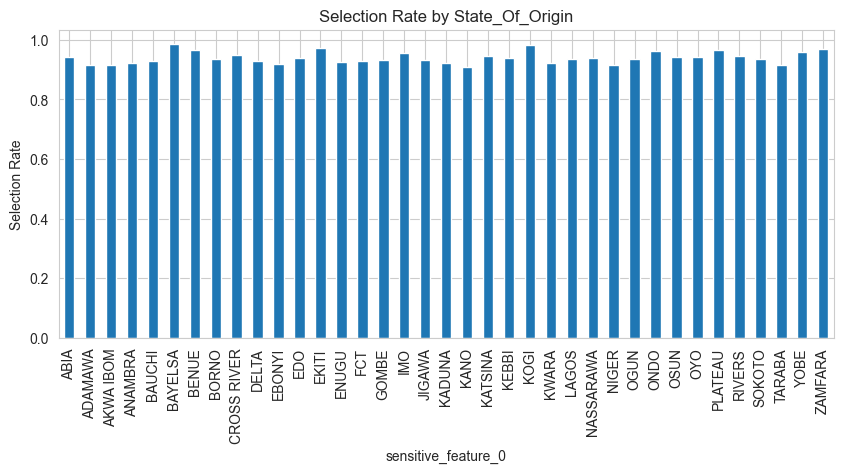

In [119]:
# Visual checks (selection rates by group)
plt.figure(figsize=(10,4))
sel_rates.plot(kind='bar')
plt.title('Selection Rate by '+sensitive)
plt.ylabel('Selection Rate')
plt.show()

```NOTE```  

**Interpretation:**  
Very near parity — no adverse impact detected for State of Origin.  

However, it is worth noting that fairness is multi-dimensional. A pass on AIR does not mean the promotion process is perfectly fair — it means there is no statistical evidence (on audited attributes/content) of adverse impact by those attributes given available features and modeling choices.

## Overall Business interpretation for the Project
This section explains how my results answer the business question “Is the promotion process biased? What should determine promotion?”  

* Key merit signals strongly associated with promotion are training performance, targets met, prior awards, and recent performance scores. These are good candidates to form an objective promotion-scoring engine because they map to observable performance and skill measures.
> Business implication: Build a promotion eligibility score that weights these merit-based metrics heavily and transparently.

* Division and location have material influence on promotions. This may reflect real differences in promotion opportunities (some divisions have more roles, faster turnover, or clearer promotion pipelines), or it may reflect inconsistent application of criteria.
> Business implication: If promotions should be equally accessible across divisions, then division-adjusted thresholds, quotas, or normalized scoring may be needed.

* Gender and marital status fairness audits do not indicate an adverse impact under standard metrics; BUT absolute counts and perceptions (e.g., more promoted males in counts) fuel complaints. Perception matters.
> Business implication: Communicate rates and normalized metrics (not just counts). Publish the promotion criteria and the score components.

* Model performance trade-offs: If the manager choose a model like Gradient Boosting, they minimize false promotions (high precision) but miss candidates (low recall). If the manager's goal is to find every promotable candidate (high recall), they need a different approach or an intermediate two-stage process (screen broadly then apply higher-precision review).

## Limitations and caveats
* Class imbalance is extreme (≈ 10.8:1). This affects model training and evaluation. Metrics must be interpreted with imbalance in mind.
* Causality vs correlation: The models identify associations, not causal effects. For example, being in Commercial Sales may correlate with promotion because that division has more roles or different appraisal processes — not because the division itself "deserves" promotion.
* Missing protected attributes: I could only audit fairness for attributes present in the data. If race/ethnicity, disability, religion, or other protected traits are relevant but not in the dataset, hidden bias may exist undetected.
* Measurement quality: Training_score_average and Last_performance_score quality depends on consistent, objective scoring across divisions and raters. If scores are noisy or biased, the model will propagate that bias.
* Label issues: The “promotion” label reflects historical managerial decisions — if the historical process was biased, a model trained on that label can reproduce bias unless explicitly corrected.

## Recommendations
* Publish a clear promotion framework that states the primary objective criteria and relative weighting (example: Training score 35%, Targets met 30%, Last performance 20%, Previous awards 10%, Qualifications 5%). Transparency reduces perception of bias.
* Use rate-based reporting (not just counts) in internal communications: Report selection rates by protected group (gender, marital status, state of origin), division-normalized promotion rates, and promotion rates per 100 staff to illustrate fairness.
* Establish an "Appeals" & "Audit" process: Any denied candidate can request a review - an independent panel (cross-division) reviews borderline cases.
* Two-stage selection pipeline is recommended:
      - Stage 1 (recall-oriented): Use a higher-recall model (e.g., SVC/RF ensemble) or rule-based screener to assemble a longlist of promotable staff.
      - Stage 2 (precision + human review): Apply a high-precision model (Gradient Boosting) to create a shortlist, then have a calibrated human panel review. This balances finding promotable candidates and avoiding false promotions.
* Normalize for division/role availability: When promotion slots are limited by division/structure, report promotions as rate per eligible population, and (where possible) create cross-division mobility programs.
* Improve and standardize performance measurement (training scores, appraisal rubrics).
* Quantitative KPI for promotions: Establish a promotion-dashboard for leadership with key metrics, trends, and outlier alerts.
* Collect richer demographic & contextual data (only as legally permitted) to enable broader fairness audits (age, disability, ethnicity). Ensure data privacy and legal compliance.
* Create development pipelines: Make trainings and assignments available across divisions to reduce structural inequity. Track who gets development opportunities.  

For a more technical audience...
* Adopt the consensus feature set for any promotion scoring tool: i.e. training_score_average, targets_met, previous_award, last_performance_score, qualification_level. Use division only as an adjustment or tie-breaker (and never as a replacement for merit).
* Bias mitigation: If future audits show disparities, apply reweighting or post-processing fairness techniques (e.g. equalized odds post-processing) rather than naive removal of features.
* Model monitoring and periodic audits: Track selection rates, TPR, precision, recall, and fairness metrics monthly or quarterly. Keep model versioning and a log of decisions.
* Human-in-the-loop: Never fully automate promotions. Use models to recommend and prioritize, not to decide. All final promotions should be reviewed by a calibrated, diverse panel.
* Calibration & thresholding: For score-based decisions, calibrate model output to reflect actual probabilities of promotion and set thresholds transparently. Consider different thresholds per division if promotion dynamics differ, but document the business logic clearly.

## Conclusion
Final verdict — Was the promotion process biased?  

Short answer: No clear statistical evidence of bias was found for Gender, Marital status, or State of Origin when audited under standard selection-rate based tests (Adverse Impact Ratio > 0.8).  

However, there are meaningful disparities in promotion counts and rates across Division, State of Origin, Recruitment Channel, and Qualification, which are legitimate matters for investigation. These disparities can drive perceptions of unfairness even if protected-group AIRs are within accepted thresholds.  

Historical processes and measurement quality can hide biases. The model inherits historical managerial decisions — if those were biased in subtle ways, the model can reproduce them unless corrected.  

Finally, the evidence does not support a claim of outright, systemic (gender, marital status, or state of origin) discrimination in promotions based on the metrics audited, but the company should act to remove ambiguity, increase transparency, normalize division differences, improve measurement, and continue fairness monitoring. That combination will reduce both real unfairness and the perception of unfairness.
